In [ ]:
# # Montar o Google Drive se estiver no Colab e os caminhos forem do Drive
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True) # Descomente se necessário

# # Instalar dependências antes de importar
# !pip install -r /content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/requirements.txt

In [ ]:
# -*- coding: utf-8 -*-
"""
00_ingestao_mdr_s2id_v1.py

Este script é responsável pela ingestão, transformação e agregação de dados
de desastres do S2ID (Sistema Integrado de Informações sobre Desastres) e
dados geoespaciais do IBGE.

Otimizações aplicadas:
- Remoção de comandos !pip install (devem ser gerenciados por requirements.txt).
- Identificação de parâmetros que poderiam ser movidos para um arquivo de configuração.
- Funções mantidas para modularidade.
- Comentários adicionados para maior clareza.
"""

# Montar o Google Drive se estiver no Colab e os caminhos forem do Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True) # Descomente se necessário

# Instalar dependências antes de importar
!pip install -r /content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/requirements.txt

# Manipulação de dados
import os
import glob
import re # Importar o módulo re para usar re.sub se necessário
import requests # Considerar adicionar ao requirements.txt
import numpy as np
import pandas as pd
import h3pandas # Considerar adicionar ao requirements.txt
import geopandas as gpd # Considerar adicionar ao requirements.txt
from unidecode import unidecode # Considerar adicionar ao requirements.txt
from datetime import datetime, timedelta

# import PyPDF2 # Se necessário para outras funcionalidades, adicionar ao requirements.txt
# import openpyxl # Se necessário para outras funcionalidades, adicionar ao requirements.txt

# --- Parâmetros Configuráveis (Exemplos para um futuro config.yaml) ---
# IBGE_DATA_PATH = '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/ibge/silver/municipios/'
# IBGE_FILE_NAME = 'BR_Municipios_2022_H3.geoparquet'
# S2ID_ATLAS_PATH = '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/s2id_atlas/s2id_atlas.csv'
# S2ID_REPORTS_PATH = '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/'
# OUTPUT_SILVER_PATH = '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/02_silver/'
# UFS_OF_INTEREST = [
#     "AC", "AL", "AP", "AM", "BA", "CE", "DF", "ES", "GO", "MA", "MT", "MS",
#     "MG", "PA", "PB", "PR", "PE", "PI", "RJ", "RN", "RS", "RO", "RR", "SC",
#     "SP", "SE", "TO"
# ]
# VALIDITY_DAYS = 90
# H3_RESOLUTION = 7 # Exemplo de resolução para H3, se aplicável na geração da malha
# POPULATION_COLUMN_NAME = 'CENSO_2020_POP' # Adicionado para centralizar o nome da coluna de população
# ------------------------------------------------------------------------

def read_geoparquet_municipios(path, filename, ufs_of_interest=None):
    """
    Carrega dados geoespaciais de um arquivo GeoParquet, pré-processa os nomes dos municípios
    e opcionalmente filtra por UF.

    Args:
        path (str): Caminho do diretório onde o arquivo de dados geoespaciais está armazenado.
        filename (str): Nome do arquivo de dados geoespaciais.
        ufs_of_interest (list of str, optional): Lista de UFs para filtrar os dados.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame com os dados geoespaciais processados.
    """
    file_path = os.path.join(path, filename)
    print(f"Lendo dados de municípios de: {file_path}")
    municipios = gpd.read_parquet(file_path)

    if ufs_of_interest:
        municipios = municipios[municipios['SIGLA_UF'].isin(ufs_of_interest)]

    municipios['NM_MUN_SEM_ACENTO'] = municipios['NM_MUN'].apply(unidecode).str.upper()
    return municipios

def aggregate_geospatial_data(geo_df, summary_df, mun_code_col='CD_MUN', uf_col='SIGLA_UF', mun_name_col='NM_MUN_SEM_ACENTO', pop_col='CENSO_2020_POP'):
    """
    Agrega dados geoespaciais com um DataFrame de resumo, mesclando-os nas chaves especificadas.
    Evita duplicação da coluna de população.

    Args:
        geo_df (gpd.GeoDataFrame): GeoDataFrame contendo os dados geoespaciais dos municípios (fonte primária da população).
        summary_df (pd.DataFrame): DataFrame contendo dados resumidos de desastres.
        mun_code_col (str): Nome da coluna de código do município em geo_df. (Não usado diretamente no merge aqui, mas mantido para consistência)
        uf_col (str): Nome da coluna da sigla da UF.
        mun_name_col (str): Nome da coluna do nome do município (sem acento, maiúsculo).
        pop_col (str): Nome da coluna de população.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame agregado com dados geoespaciais e de resumo.
    """
    print("Agregando dados geoespaciais com dados de desastres...")
    merge_cols = [uf_col, mun_name_col] # Chaves de junção

    # Validação das chaves de junção
    if not all(col in geo_df.columns for col in merge_cols):
        raise ValueError(f"Colunas de junção {merge_cols} não encontradas em geo_df (DataFrame geoespacial).")
    if not all(col in summary_df.columns for col in merge_cols):
        raise ValueError(f"Colunas de junção {merge_cols} não encontradas em summary_df (DataFrame de resumo).")

    # Para evitar colunas duplicadas de população (_x, _y), verificamos se a coluna de população
    # existe em ambos os DataFrames. Se sim, removemos do summary_df antes do merge,
    # pois consideramos geo_df como a fonte primária da informação de população.
    summary_df_processed = summary_df.copy()
    if pop_col in summary_df_processed.columns and pop_col in geo_df.columns:
        print(f"Removendo coluna '{pop_col}' de summary_df antes do merge para evitar duplicação.")
        summary_df_processed = summary_df_processed.drop(columns=[pop_col])

    # Realizar o merge
    merged_df = geo_df.merge(summary_df_processed, how='left', on=merge_cols)

    merged_df = merged_df.drop_duplicates()
    # Considerar se fillna(0) é apropriado para todas as colunas ou se deve ser mais seletivo.
    # Para contagens de desastres, 0 é geralmente ok. Para outras métricas, pode não ser.
    merged_df.fillna(0, inplace=True)
    return merged_df

def read_s2id_files(path, extension='csv', header=1, skiprows=3, sep=';', encoding="ISO-8859-1"):
    """
    Lê e agrega múltiplos arquivos CSV (relatórios S2ID) em um único DataFrame.
    """
    full_path_pattern = os.path.join(path, f"*.{extension}")
    all_filenames = glob.glob(full_path_pattern)

    if not all_filenames:
        print(f"Nenhum arquivo .{extension} encontrado em {path}")
        return pd.DataFrame()

    print(f"Arquivos S2ID encontrados para leitura: {all_filenames}")
    df_list = []
    for f in all_filenames:
        try:
            df_list.append(pd.read_csv(f, header=header, skiprows=skiprows, sep=sep, encoding=encoding, low_memory=False))
        except Exception as e:
            print(f"Erro ao ler o arquivo {f}: {e}")
            continue

    if not df_list:
        print("Nenhum arquivo S2ID pôde ser lido.")
        return pd.DataFrame()

    return pd.concat(df_list, ignore_index=True)

def transform_s2id_data(df, source_type="report"):
    """
    Transforma os dados do S2ID, normalizando colunas, datas e extraindo informações.

    Args:
        df (pd.DataFrame): DataFrame com dados brutos do S2ID.
        source_type (str): "report" para dados dos relatórios S2ID, "atlas" para dados do Atlas Digital.

    Returns:
        pd.DataFrame: DataFrame transformado.
    """
    print(f"Transformando dados S2ID (origem: {source_type})...")
    df_transformed = df.copy()

    df_transformed.columns = df_transformed.columns.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
    df_transformed.columns = map(str.upper, df_transformed.columns)

    if source_type == "report":
        if 'REGISTRO' in df_transformed.columns:
            df_transformed['DATA_REGISTRO'] = pd.to_datetime(df_transformed['REGISTRO'], dayfirst=True, errors='coerce')
        else:
            print("Aviso: Coluna 'REGISTRO' não encontrada para dados do tipo 'report'.")
            df_transformed['DATA_REGISTRO'] = pd.NaT

        if 'PROTOCOLO' in df_transformed.columns:
            df_transformed['CD_MUN'] = df_transformed['PROTOCOLO'].astype(str).str[5:12]
        if 'COBRADE' in df_transformed.columns:
            df_transformed['COD_COBRADE'] = df_transformed['COBRADE'].astype(str).str[0:5]
            df_transformed['COBRADE_NAME'] = df_transformed['COBRADE'].astype(str).str[7:]

        df_transformed = df_transformed.rename(columns={'UF': 'SIGLA_UF', 'MUNICIPIO': 'NM_MUN'}, errors='ignore')

    elif source_type == "atlas":
        rename_map_atlas = {
            'PROTOCOLO_S2ID':'PROTOCOLO', 'NOME_MUNICIPIO':'NM_MUN',
            'DM_UNI_HABITA_DANIFICADAS':'DM_UNIDADES_HABITACIONAIS_DANIFICADAS',
            'COD_COBRADE': 'COD_COBRADE',
            'CD_IBGE_MUN': 'CD_MUN', # Nome original no CSV: Cod_IBGE_Mun
            'SIGLA_UF': 'SIGLA_UF' # Assegurar que SIGLA_UF existe
        }
        # Adicionar mais renomeações do script original, adaptadas para maiúsculas
        # Exemplo: 'DM_UNI_HABITA_DESTRUIDAS': 'DM_UNIDADES_HABITACIONAIS_DESTRUIDAS'
        df_transformed = df_transformed.rename(columns=rename_map_atlas, errors='ignore')

        if 'COD_COBRADE' in df_transformed.columns:
            df_transformed['COD_COBRADE'] = df_transformed['COD_COBRADE'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
        if 'CD_MUN' in df_transformed.columns: # CD_MUN também pode precisar de limpeza se vier como float
            df_transformed['CD_MUN'] = df_transformed['CD_MUN'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)


        cols_to_drop_atlas = ['REGIAO','SETORES_CENSITARIOS','DH_DESCRICAO', 'DM_DESCRICAO', 'DA_DESCRICAO', 'PEPL_DESCRICAO', 'PEPR_DESCRICAO']
        df_transformed = df_transformed.drop(columns=[col for col in cols_to_drop_atlas if col in df_transformed.columns], axis=1, errors='ignore')

        if 'DATA_REGISTRO' in df_transformed.columns:
            df_transformed['DATA_REGISTRO'] = pd.to_datetime(df_transformed['DATA_REGISTRO'], dayfirst=True, errors='coerce')
        else:
            print("Aviso: Coluna 'DATA_REGISTRO' não encontrada para dados do tipo 'atlas'.")
            df_transformed['DATA_REGISTRO'] = pd.NaT

        if 'DATA_EVENTO' in df_transformed.columns:
            df_transformed['DATA_EVENTO'] = pd.to_datetime(df_transformed['DATA_EVENTO'], dayfirst=True, errors='coerce')
        else:
            print("Aviso: Coluna 'DATA_EVENTO' não encontrada para dados do tipo 'atlas'.")

    if 'DATA_REGISTRO' in df_transformed.columns and pd.api.types.is_datetime64_any_dtype(df_transformed['DATA_REGISTRO']):
        df_transformed['ANO'] = df_transformed['DATA_REGISTRO'].dt.year
        df_transformed['MES'] = df_transformed['DATA_REGISTRO'].dt.month
        df_transformed = df_transformed.sort_values(by='DATA_REGISTRO', ascending=True)
    else:
        col_type = df_transformed['DATA_REGISTRO'].dtype if 'DATA_REGISTRO' in df_transformed.columns else "Não encontrada"
        print(f"Aviso: Coluna 'DATA_REGISTRO' não é do tipo datetime ({col_type}) ou não foi criada. Não foi possível extrair ANO/MES.")
        if 'DATA_REGISTRO' in df_transformed.columns and not pd.api.types.is_datetime64_any_dtype(df_transformed['DATA_REGISTRO']):
             print(f"Primeiros valores de DATA_REGISTRO problemáticos: {df_transformed['DATA_REGISTRO'].head().to_list()}")

    if 'NM_MUN' in df_transformed.columns:
        df_transformed['NM_MUN_SEM_ACENTO'] = df_transformed['NM_MUN'].apply(lambda x: unidecode(str(x))).str.upper()
    else:
        print("Aviso: Coluna 'NM_MUN' não encontrada para criar 'NM_MUN_SEM_ACENTO'.")

    return df_transformed

def get_cobrade_details(df_main, df_reference, cobrade_col_main='COD_COBRADE', cobrade_col_ref='COD_COBRADE', details_cols_ref=None):
    if details_cols_ref is None:
        details_cols_ref = ['TIPOLOGIA', 'DESCRICAO_TIPOLOGIA', 'GRUPO_DE_DESASTRE']

    print(f"Adicionando detalhes do COBRADE: {details_cols_ref}")

    if cobrade_col_main not in df_main.columns:
        print(f"Aviso: Coluna de junção '{cobrade_col_main}' não encontrada em df_main. Pulando adição de detalhes.")
        return df_main
    if cobrade_col_ref not in df_reference.columns:
        print(f"Aviso: Coluna de junção '{cobrade_col_ref}' não encontrada em df_reference. Pulando adição de detalhes.")
        return df_main

    df_main_copy = df_main.copy()
    df_reference_copy = df_reference.copy()

    df_main_copy[cobrade_col_main] = df_main_copy[cobrade_col_main].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
    df_reference_copy[cobrade_col_ref] = df_reference_copy[cobrade_col_ref].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

    existing_details_cols_ref = [col for col in details_cols_ref if col in df_reference_copy.columns]
    if not existing_details_cols_ref:
        print(f"Aviso: Nenhuma das colunas de detalhe especificadas ({details_cols_ref}) existe em df_reference. Pulando adição de detalhes.")
        return df_main_copy

    df_ref_unique = df_reference_copy[[cobrade_col_ref] + existing_details_cols_ref].drop_duplicates(subset=[cobrade_col_ref], keep='first')

    df_merged = df_main_copy.merge(df_ref_unique, left_on=cobrade_col_main, right_on=cobrade_col_ref, how='left', suffixes=('', '_ref'))

    if cobrade_col_main != cobrade_col_ref and f"{cobrade_col_ref}_ref" in df_merged.columns:
        df_merged = df_merged.drop(columns=[f"{cobrade_col_ref}_ref"])
    elif cobrade_col_main != cobrade_col_ref and cobrade_col_ref in df_merged.columns and cobrade_col_ref != cobrade_col_main:
        df_merged = df_merged.drop(columns=[cobrade_col_ref])

    return df_merged


def summarize_disasters_by_period(df, periods_config, cobrades_of_interest=None, validity_days=90, date_col='DATA_REGISTRO', group_by_cols=None):
    if group_by_cols is None:
        group_by_cols = ['COD_COBRADE', 'SIGLA_UF', 'NM_MUN_SEM_ACENTO', 'VALIDITY']

    print("Resumindo desastres por período...")
    df_filtered = df.copy()

    if cobrades_of_interest is not None and len(cobrades_of_interest) > 0:
        cobrades_of_interest_str = []
        for c in cobrades_of_interest:
            s = str(c).strip()
            if s.endswith('.0'):
                s = s[:-2]
            cobrades_of_interest_str.append(s)

        if 'COD_COBRADE' in df_filtered.columns:
            df_filtered['COD_COBRADE'] = df_filtered['COD_COBRADE'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
            df_filtered = df_filtered[df_filtered['COD_COBRADE'].isin(cobrades_of_interest_str)]
        else:
            print("Aviso: Coluna 'COD_COBRADE' não encontrada em df_filtered para filtrar por cobrades_of_interest.")
    elif cobrades_of_interest is not None:
        print("Aviso: cobrades_of_interest está vazio. Nenhum filtro por COBRADE será aplicado.")

    if date_col not in df_filtered.columns or not pd.api.types.is_datetime64_any_dtype(df_filtered[date_col]):
        print(f"Aviso: Coluna de data '{date_col}' não encontrada ou não é do tipo datetime. Não é possível calcular VALIDITY ou filtrar por período.")
        df_filtered['VALIDITY'] = 'Indeterminado'
    else:
        validity_cutoff = datetime.now() - timedelta(days=validity_days)
        df_filtered['VALIDITY'] = df_filtered[date_col].apply(lambda x: 'Sim' if pd.notnull(x) and x >= validity_cutoff else 'Não')

    all_period_summaries = []
    for period_name, (start_years_ago, end_years_ago) in periods_config.items():
        if date_col not in df_filtered.columns or not pd.api.types.is_datetime64_any_dtype(df_filtered[date_col]):
            print(f"Pulando período {period_name} devido à ausência/tipo incorreto da coluna de data.")
            empty_summary_cols = [col for col in group_by_cols if col in df_filtered.columns] + [f'{period_name}_COUNT']
            all_period_summaries.append(pd.DataFrame(columns=empty_summary_cols))
            continue

        start_date = datetime.now() - timedelta(days=365.25 * start_years_ago)
        end_date = datetime.now() - timedelta(days=365.25 * end_years_ago)

        if end_years_ago == 0:
            end_date = datetime.now()

        period_df = df_filtered[(df_filtered[date_col] >= start_date) & (df_filtered[date_col] <= end_date)]

        current_group_by_cols = [col for col in group_by_cols if col in period_df.columns]
        if not current_group_by_cols:
            print(f"Aviso: Nenhuma coluna de agrupamento válida para o período {period_name}. Pulando.")
            all_period_summaries.append(pd.DataFrame(columns=group_by_cols + [f'{period_name}_COUNT']))
            continue

        aggregated_data = period_df.groupby(current_group_by_cols).size().reset_index(name=f'{period_name}_COUNT')
        all_period_summaries.append(aggregated_data)

    if not all_period_summaries:
        print("Nenhum resumo de período pôde ser gerado.")
        return pd.DataFrame()

    from functools import reduce
    if len(all_period_summaries) == 1:
        summary_df = all_period_summaries[0]
    else:
        merge_on_cols = [col for col in group_by_cols if col in all_period_summaries[0].columns]
        all_period_summaries = [df for df in all_period_summaries if not df.empty]
        if not all_period_summaries:
            return pd.DataFrame()
        if len(all_period_summaries) == 1:
             summary_df = all_period_summaries[0]
        else:
            # Garantir que as colunas de merge realmente existem em todos os dataframes antes do merge
            # Isso é um pouco mais complexo, mas para o outer merge, o pandas lida bem se uma coluna não existe em um dos lados
            # No entanto, é bom garantir que as colunas chave estejam presentes.
            def safe_merge(df1, df2):
                common_merge_cols = [col for col in merge_on_cols if col in df1.columns and col in df2.columns]
                if not common_merge_cols and (not df1.empty and not df2.empty): # Evitar erro se um df for vazio e não tiver colunas
                     print(f"Aviso: Nenhuma coluna de merge comum encontrada entre dataframes para reduce. Verifique group_by_cols e os dataframes de período. Tentando merge no índice se possível ou retornando concatenação.")
                     # Fallback muito simples, pode não ser o ideal
                     return pd.concat([df1, df2], ignore_index=True) if df1.columns.equals(df2.columns) else pd.merge(df1, df2, how='outer', on=df1.index.names if df1.index.names == df2.index.names else None)

                return pd.merge(df1, df2, on=common_merge_cols, how='outer')

            summary_df = reduce(safe_merge, all_period_summaries)


    return summary_df.fillna(0)


def aggregate_and_pivot_summary(summary_df, municipios_pop_df, periods_config, pop_col='CENSO_2020_POP'):
    print("Agregando sumário, ponderando pela população e pivotando...")

    if summary_df.empty:
        print("Aviso: summary_df está vazio. Retornando DataFrame vazio.")
        return pd.DataFrame()

    count_cols = [f'{p}_COUNT' for p in periods_config.keys() if f'{p}_COUNT' in summary_df.columns]
    if not count_cols:
        print("Aviso: Nenhuma coluna de contagem ('_COUNT') encontrada em summary_df baseada em periods_config.")

    agg_funcs = {col: 'sum' for col in count_cols}

    group_cols_agg_city = [col for col in ['SIGLA_UF', 'NM_MUN_SEM_ACENTO'] if col in summary_df.columns]
    if not group_cols_agg_city:
        print("Aviso: Colunas de agrupamento ('SIGLA_UF', 'NM_MUN_SEM_ACENTO') não encontradas em summary_df para agregação por cidade.")
        return pd.DataFrame()

    summary_by_city = summary_df.groupby(group_cols_agg_city).agg(agg_funcs).reset_index()

    if not all(col in municipios_pop_df.columns for col in ['SIGLA_UF', 'NM_MUN_SEM_ACENTO', pop_col]):
         raise ValueError(f"Colunas ['SIGLA_UF', 'NM_MUN_SEM_ACENTO', '{pop_col}'] não encontradas em municipios_pop_df.")

    summary_by_city_pop = summary_by_city.merge(
        municipios_pop_df[['SIGLA_UF', 'NM_MUN_SEM_ACENTO', pop_col]],
        on=group_cols_agg_city,
        how='left'
    )
    summary_by_city_pop[pop_col] = pd.to_numeric(summary_by_city_pop[pop_col], errors='coerce').fillna(0)

    for col in count_cols:
        summary_by_city_pop[f'{col}_POR_10K_HAB'] = np.where(
            summary_by_city_pop[pop_col] > 0,
            (summary_by_city_pop[col] / summary_by_city_pop[pop_col]) * 10000,
            0
        )

    # Adicionar população ao summary_df original para calcular taxas por COBRADE antes de pivotar
    # Assegurar que group_cols_agg_city existem em summary_df
    if not all(c in summary_df.columns for c in group_cols_agg_city):
        print(f"Aviso: Nem todas as colunas de {group_cols_agg_city} existem em summary_df. O merge para summary_df_pop pode falhar ou ser incompleto.")
        # Se as colunas não existirem, este merge não funcionará como esperado.
        # Pode ser necessário um tratamento de erro mais robusto aqui ou garantir que summary_df sempre as tenha.
        summary_df_pop = summary_df.copy() # Evitar erro, mas taxas por COBRADE podem não ser calculadas
        if pop_col not in summary_df_pop.columns : summary_df_pop[pop_col] = 0 # Adicionar coluna de população zerada
    else:
        summary_df_pop = summary_df.merge(
            municipios_pop_df[['SIGLA_UF', 'NM_MUN_SEM_ACENTO', pop_col]],
            on=group_cols_agg_city,
            how='left'
        )
        summary_df_pop[pop_col] = pd.to_numeric(summary_df_pop[pop_col], errors='coerce').fillna(0)


    rate_cols_per_cobrade = []
    for col in count_cols:
        rate_col_name = f'{col}_POR_10K_HAB'
        summary_df_pop[rate_col_name] = np.where(
            summary_df_pop[pop_col] > 0, # pop_col aqui é de summary_df_pop
            (summary_df_pop[col] / summary_df_pop[pop_col]) * 10000,
            0
        )
        rate_cols_per_cobrade.append(rate_col_name)

    values_to_pivot = count_cols + rate_cols_per_cobrade

    if 'COD_COBRADE' not in summary_df_pop.columns:
        print("Aviso: Coluna 'COD_COBRADE' não encontrada em summary_df_pop. Não é possível pivotar por COBRADE.")
        return summary_by_city_pop.fillna(0) # Retorna o DataFrame agregado por cidade, mas não pivotado

    summary_df_pop['COD_COBRADE'] = summary_df_pop['COD_COBRADE'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

    # Verificar se group_cols_agg_city ainda são válidas para index do pivot_table
    valid_index_cols_pivot = [col for col in group_cols_agg_city if col in summary_df_pop.columns]
    if not valid_index_cols_pivot:
        print("Aviso: Nenhuma coluna de índice válida para pivot_table. Retornando summary_by_city_pop.")
        return summary_by_city_pop.fillna(0)

    pivot_df = summary_df_pop.pivot_table(
        index=valid_index_cols_pivot,
        columns='COD_COBRADE',
        values=values_to_pivot,
        aggfunc='sum',
        fill_value=0
    )
    pivot_df.columns = ['_'.join(str(s).strip() for s in col if s != '').upper() for col in pivot_df.columns.values]
    pivot_df.reset_index(inplace=True)

    final_df = summary_by_city_pop.merge(pivot_df, on=valid_index_cols_pivot, how='left')
    return final_df.fillna(0)


def clean_value_columns(df, columns_to_clean_keywords=None):
    if columns_to_clean_keywords is None:
        columns_to_clean_keywords = ['VALOR', 'R$', 'POP', 'CUSTO']

    print(f"Limpando colunas de valor contendo: {columns_to_clean_keywords}")

    def _clean_convert(value):
        if isinstance(value, str):
            cleaned_value = ''.join(c for c in value if c.isdigit() or c in '.,')
            cleaned_value = cleaned_value.replace(',', '.')
            try:
                return float(cleaned_value)
            except ValueError:
                return np.nan
        elif pd.isna(value):
            return np.nan
        return value

    for col_keyword in columns_to_clean_keywords:
        for col_name in df.columns:
            if col_keyword.upper() in col_name.upper():
                if df[col_name].dtype == 'object':
                    print(f"Limpando coluna: {col_name}")
                    df[col_name] = df[col_name].apply(_clean_convert)
    return df

# --- Bloco Principal de Execução ---
def main_ingestion(config):
    """
    Executa o pipeline de ingestão e processamento de dados.
    """
    print("Iniciando pipeline de ingestão e processamento de dados S2ID...")
    pop_col_name = config.get('POPULATION_COLUMN_NAME', 'CENSO_2020_POP') # Pega do config ou usa default

    municipios_gdf = read_geoparquet_municipios(config['IBGE_DATA_PATH'], config['IBGE_FILE_NAME'], config['UFS_OF_INTEREST'])
    municipios_gdf = municipios_gdf.drop(columns=['index','CENSO_2010_POP','TX_CRESC','VAR_ABS'], errors='ignore')

    municipios_dissolve_gdf = municipios_gdf.copy().dissolve(by='CD_MUN').reset_index()
    if 'h3_polyfill' in municipios_dissolve_gdf.columns:
        municipios_dissolve_gdf = municipios_dissolve_gdf.drop(columns=['h3_polyfill'])

    atlas_raw_df = pd.read_csv(config['S2ID_ATLAS_PATH'], sep=';', encoding='Latin-1', low_memory=False)
    atlas_transformed_df = transform_s2id_data(atlas_raw_df, source_type="atlas")

    reports_raw_df = read_s2id_files(config['S2ID_REPORTS_PATH'], sep=';', encoding='ISO-8859-1')
    reports_transformed_df = transform_s2id_data(reports_raw_df, source_type="report")

    cobrade_details_cols_options = ['COBRADE', 'COBRADE_NAME', 'TIPOLOGIA', 'DESCRICAO_TIPOLOGIA', 'GRUPO_DE_DESASTRE']

    actual_cobrade_details_from_atlas = [col for col in cobrade_details_cols_options if col in atlas_transformed_df.columns]
    if actual_cobrade_details_from_atlas:
        reports_transformed_df = get_cobrade_details(reports_transformed_df, atlas_transformed_df,
                                                 details_cols_ref=actual_cobrade_details_from_atlas)
    else:
        print("Aviso: Nenhuma coluna de detalhe COBRADE encontrada no Atlas para adicionar aos Reports.")

    actual_cobrade_details_from_reports = [col for col in cobrade_details_cols_options if col in reports_transformed_df.columns]
    if actual_cobrade_details_from_reports:
         atlas_transformed_df = get_cobrade_details(atlas_transformed_df, reports_transformed_df,
                                                 details_cols_ref=actual_cobrade_details_from_reports)
    else:
        print("Aviso: Nenhuma coluna de detalhe COBRADE encontrada nos Reports para adicionar ao Atlas.")

    # Garantir que as colunas chave para concatenação existam em ambos os dataframes
    cols_atlas = set(atlas_transformed_df.columns)
    cols_reports = set(reports_transformed_df.columns)
    common_cols = list(cols_atlas.intersection(cols_reports))

    if not common_cols:
        print("Erro: Nenhuma coluna em comum entre Atlas transformado e Reports transformado. Verifique a transformação.")
        historical_df = pd.DataFrame()
    else:
        print(f"Colunas comuns para concatenação: {common_cols}")
        # Para garantir que a ordem das colunas seja a mesma e evitar problemas de concatenação de tipos diferentes
        # é melhor selecionar explicitamente as colunas em ambos antes de concatenar.
        historical_df = pd.concat(
            [atlas_transformed_df[common_cols], reports_transformed_df[common_cols]],
            ignore_index=True, sort=False
        )
        if 'PROTOCOLO' in historical_df.columns:
            historical_df = historical_df.drop_duplicates(subset=['PROTOCOLO'])
        else:
            print("Aviso: Coluna 'PROTOCOLO' não encontrada em historical_df para remover duplicatas.")
            historical_df = historical_df.drop_duplicates()

    historical_df = clean_value_columns(historical_df, columns_to_clean_keywords=['VALOR', 'R$', 'POP', 'CUSTO'])

    periods_config = {
        'HISTORIC': (100, 0),
        'LAST10_YEARS': (10, 0),
        'LAST05_YEARS': (5, 0),
        'LAST02_YEARS': (2, 0)
    }

    if 'COD_COBRADE' in historical_df.columns:
        historical_df['COD_COBRADE'] = historical_df['COD_COBRADE'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
        cobrades_all = historical_df['COD_COBRADE'].unique()
    else:
        cobrades_all = []
        print("Aviso: Coluna 'COD_COBRADE' não encontrada em historical_df para definir cobrades_all.")

    summary_df = summarize_disasters_by_period(historical_df, periods_config, cobrades_all, config['VALIDITY_DAYS'])

    pivot_final_df = aggregate_and_pivot_summary(summary_df, municipios_dissolve_gdf, periods_config, pop_col=pop_col_name)

    disaster_analysis_gdf = aggregate_geospatial_data(
        municipios_dissolve_gdf.drop(columns=['NM_MUN'], errors='ignore'),
        pivot_final_df,
        pop_col=pop_col_name # Passar o nome da coluna de população
    )

    if pop_col_name in disaster_analysis_gdf.columns:
        disaster_analysis_gdf[pop_col_name] = disaster_analysis_gdf[pop_col_name].astype(int)

    output_path_decree = os.path.join(config['OUTPUT_SILVER_PATH'], 'climate_decree_s2id.geoparquet')
    output_path_risk = os.path.join(config['OUTPUT_SILVER_PATH'], 'climate_risk.geoparquet')

    if not historical_df.empty and 'CD_MUN' in municipios_dissolve_gdf.columns and 'geometry' in municipios_dissolve_gdf.columns:
        # Tentar merge com CD_MUN se existir em historical_df, senão tentar com chaves compostas
        historical_df_for_merge = historical_df.copy()
        if 'CD_MUN' not in historical_df_for_merge.columns and all(k in historical_df_for_merge.columns for k in ['NM_MUN_SEM_ACENTO', 'SIGLA_UF']):
            print("Tentando merge de historical_df com geometria usando NM_MUN_SEM_ACENTO e SIGLA_UF.")
            # Preparar municipios_dissolve_gdf para este merge
            geo_keys_df = municipios_dissolve_gdf[['NM_MUN_SEM_ACENTO', 'SIGLA_UF', 'geometry']].drop_duplicates()
            historical_with_geom_df = geo_keys_df.merge(historical_df_for_merge, on=['NM_MUN_SEM_ACENTO', 'SIGLA_UF'], how='right')
        elif 'CD_MUN' in historical_df_for_merge.columns:
            if historical_df_for_merge['CD_MUN'].dtype != municipios_dissolve_gdf['CD_MUN'].dtype:
                print(f"Aviso: Dtypes da coluna 'CD_MUN' diferem. Tentando converter historical_df['CD_MUN'].")
                try:
                    historical_df_for_merge['CD_MUN'] = historical_df_for_merge['CD_MUN'].astype(municipios_dissolve_gdf['CD_MUN'].dtype)
                except Exception as e:
                    print(f"Erro ao converter dtype de CD_MUN em historical_df: {e}.")
            historical_with_geom_df = municipios_dissolve_gdf[['CD_MUN', 'geometry']].merge(historical_df_for_merge, on='CD_MUN', how='right')
        else:
            print("Não foi possível determinar chaves para unir historical_df com geometria.")
            historical_with_geom_df = pd.DataFrame() # Vazio para indicar falha no merge

        if not historical_with_geom_df.empty and 'geometry' in historical_with_geom_df:
            historical_with_geom_gdf = gpd.GeoDataFrame(historical_with_geom_df, geometry='geometry', crs=municipios_dissolve_gdf.crs)
            if not historical_with_geom_gdf.empty:
                 historical_with_geom_gdf.to_parquet(output_path_decree)
                 print(f"Salvo: {output_path_decree}")
            else:
                print(f"DataFrame historical_with_geom_gdf está vazio após conversão para GeoDataFrame. Não salvo.")
                historical_df.to_parquet(output_path_decree.replace(".geoparquet", ".parquet"))
                print(f"Salvo (sem geometria): {output_path_decree.replace('.geoparquet', '.parquet')}")
        else:
            print(f"DataFrame historical_with_geom_df está vazio ou sem geometria após merge. Não salvo com geometria.")
            historical_df.to_parquet(output_path_decree.replace(".geoparquet", ".parquet"))
            print(f"Salvo (sem geometria): {output_path_decree.replace('.geoparquet', '.parquet')}")

    elif not historical_df.empty:
        historical_df.to_parquet(output_path_decree.replace(".geoparquet", ".parquet"))
        print(f"Salvo (sem geometria, pois não foi possível unir com geometria): {output_path_decree.replace('.geoparquet', '.parquet')}")
    else:
        print(f"DataFrame historical_df está vazio. Não salvo.")


    if not disaster_analysis_gdf.empty:
        disaster_analysis_gdf.to_parquet(output_path_risk)
        print(f"Salvo: {output_path_risk}")
    else:
        print(f"DataFrame disaster_analysis_gdf está vazio. Não salvo.")

    print("Pipeline de ingestão e processamento concluído.")
    return disaster_analysis_gdf, historical_df


if __name__ == '__main__':
    config_exemplo = {
        'IBGE_DATA_PATH': '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/ibge/silver/municipios/',
        'IBGE_FILE_NAME': 'BR_Municipios_2024.geoparquet', #'BR_Municipios_2023_H3.geoparquet'
        'S2ID_ATLAS_PATH': '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/s2id_atlas/s2id_atlas.csv',
        'S2ID_REPORTS_PATH': '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/',
        'OUTPUT_SILVER_PATH': '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/02_silver/',
        'UFS_OF_INTEREST': ["RS"],
        'VALIDITY_DAYS': 90,
        'POPULATION_COLUMN_NAME': 'CENSO_2020_POP' # Adicionado aqui
    }

    # from google.colab import drive
    # drive.mount('/content/drive', force_remount=True)

    os.makedirs(config_exemplo['OUTPUT_SILVER_PATH'], exist_ok=True)

    _, _ = main_ingestion(config_exemplo)
    # print("Exemplo de execução do main_ingestion (comentado).")
    # print("Descomente a linha `main_ingestion(config_exemplo)` e ajuste os caminhos para executar.")

Mounted at /content/drive
INFO: pip is looking at multiple versions of h3pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.8 MB/s eta 0:00:00
  Created wheel for h3pandas: filename=h3pandas-0.2.6-py3-none-any.whl size=19688 sha256=a03f03f37d6a5fad90347415ea2a6f53d7fce46f34bb0be0babf2622c6537ceb
  Stored in directory: /root/.cache/pip/wheels/b8/92/37/51119668d260605aa3e77ff7bc342ad2add69eaac0d77d5744
Successfully built h3pandas
Iniciando pipeline de ingestão e processamento de dados S2ID...
Lendo dados de municípios de: /content

ArrowInvalid: ("Could not convert 'Pelotas' with type str: tried to convert to int64", 'Conversion failed for column NM_RGINT with type object')

In [ ]:
import os
import glob
import re # Importar o módulo re para usar re.sub se necessário
import requests # Considerar adicionar ao requirements.txt
import numpy as np
import pandas as pd
import h3pandas # Considerar adicionar ao requirements.txt
import geopandas as gpd # Considerar adicionar ao requirements.txt
from unidecode import unidecode # Considerar adicionar ao requirements.txt
from datetime import datetime, timedelta

def read_geoparquet_municipios(path, filename, ufs_of_interest=None):
    """
    Carrega dados geoespaciais de um arquivo GeoParquet, pré-processa os nomes dos municípios
    e opcionalmente filtra por UF.

    Args:
        path (str): Caminho do diretório onde o arquivo de dados geoespaciais está armazenado.
        filename (str): Nome do arquivo de dados geoespaciais.
        ufs_of_interest (list of str, optional): Lista de UFs para filtrar os dados.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame com os dados geoespaciais processados.
    """
    file_path = os.path.join(path, filename)
    print(f"Lendo dados de municípios de: {file_path}")
    municipios = gpd.read_parquet(file_path)

    if ufs_of_interest:
        municipios = municipios[municipios['SIGLA_UF'].isin(ufs_of_interest)]

    municipios['NM_MUN_SEM_ACENTO'] = municipios['NM_MUN'].apply(unidecode).str.upper()
    return municipios

def aggregate_geospatial_data(geo_df, summary_df, mun_code_col='CD_MUN', uf_col='SIGLA_UF', mun_name_col='NM_MUN_SEM_ACENTO', pop_col='CENSO_2020_POP'):
    """
    Agrega dados geoespaciais com um DataFrame de resumo, mesclando-os nas chaves especificadas.
    Evita duplicação da coluna de população.

    Args:
        geo_df (gpd.GeoDataFrame): GeoDataFrame contendo os dados geoespaciais dos municípios (fonte primária da população).
        summary_df (pd.DataFrame): DataFrame contendo dados resumidos de desastres.
        mun_code_col (str): Nome da coluna de código do município em geo_df. (Não usado diretamente no merge aqui, mas mantido para consistência)
        uf_col (str): Nome da coluna da sigla da UF.
        mun_name_col (str): Nome da coluna do nome do município (sem acento, maiúsculo).
        pop_col (str): Nome da coluna de população.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame agregado com dados geoespaciais e de resumo.
    """
    print("Agregando dados geoespaciais com dados de desastres...")
    merge_cols = [uf_col, mun_name_col] # Chaves de junção

    # Validação das chaves de junção
    if not all(col in geo_df.columns for col in merge_cols):
        raise ValueError(f"Colunas de junção {merge_cols} não encontradas em geo_df (DataFrame geoespacial).")
    if not all(col in summary_df.columns for col in merge_cols):
        raise ValueError(f"Colunas de junção {merge_cols} não encontradas em summary_df (DataFrame de resumo).")

    # Para evitar colunas duplicadas de população (_x, _y), verificamos se a coluna de população
    # existe em ambos os DataFrames. Se sim, removemos do summary_df antes do merge,
    # pois consideramos geo_df como a fonte primária da informação de população.
    summary_df_processed = summary_df.copy()
    if pop_col in summary_df_processed.columns and pop_col in geo_df.columns:
        print(f"Removendo coluna '{pop_col}' de summary_df antes do merge para evitar duplicação.")
        summary_df_processed = summary_df_processed.drop(columns=[pop_col])

    # Realizar o merge
    merged_df = geo_df.merge(summary_df_processed, how='left', on=merge_cols)

    merged_df = merged_df.drop_duplicates()
    # Considerar se fillna(0) é apropriado para todas as colunas ou se deve ser mais seletivo.
    # Para contagens de desastres, 0 é geralmente ok. Para outras métricas, pode não ser.
    merged_df.fillna(0, inplace=True)
    return merged_df

def read_s2id_files(path, extension='csv', header=1, skiprows=3, sep=';', encoding="ISO-8859-1"):
    """
    Lê e agrega múltiplos arquivos CSV (relatórios S2ID) em um único DataFrame.
    """
    full_path_pattern = os.path.join(path, f"*.{extension}")
    all_filenames = glob.glob(full_path_pattern)

    if not all_filenames:
        print(f"Nenhum arquivo .{extension} encontrado em {path}")
        return pd.DataFrame()

    print(f"Arquivos S2ID encontrados para leitura: {all_filenames}")
    df_list = []
    for f in all_filenames:
        try:
            df_list.append(pd.read_csv(f, header=header, skiprows=skiprows, sep=sep, encoding=encoding, low_memory=False))
        except Exception as e:
            print(f"Erro ao ler o arquivo {f}: {e}")
            continue

    if not df_list:
        print("Nenhum arquivo S2ID pôde ser lido.")
        return pd.DataFrame()

    return pd.concat(df_list, ignore_index=True)

def transform_s2id_data(df, source_type="report"):
    """
    Transforma os dados do S2ID, normalizando colunas, datas e extraindo informações.

    Args:
        df (pd.DataFrame): DataFrame com dados brutos do S2ID.
        source_type (str): "report" para dados dos relatórios S2ID, "atlas" para dados do Atlas Digital.

    Returns:
        pd.DataFrame: DataFrame transformado.
    """
    print(f"Transformando dados S2ID (origem: {source_type})...")
    df_transformed = df.copy()

    df_transformed.columns = df_transformed.columns.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
    df_transformed.columns = map(str.upper, df_transformed.columns)

    if source_type == "report":
        if 'REGISTRO' in df_transformed.columns:
            df_transformed['DATA_REGISTRO'] = pd.to_datetime(df_transformed['REGISTRO'], dayfirst=True, errors='coerce')
        else:
            print("Aviso: Coluna 'REGISTRO' não encontrada para dados do tipo 'report'.")
            df_transformed['DATA_REGISTRO'] = pd.NaT

        if 'PROTOCOLO' in df_transformed.columns:
            df_transformed['CD_MUN'] = df_transformed['PROTOCOLO'].astype(str).str[5:12]
        if 'COBRADE' in df_transformed.columns:
            df_transformed['COD_COBRADE'] = df_transformed['COBRADE'].astype(str).str[0:5]
            df_transformed['COBRADE_NAME'] = df_transformed['COBRADE'].astype(str).str[7:]

        df_transformed = df_transformed.rename(columns={'UF': 'SIGLA_UF', 'MUNICIPIO': 'NM_MUN'}, errors='ignore')

    elif source_type == "atlas":
        rename_map_atlas = {
            'PROTOCOLO_S2ID':'PROTOCOLO', 'NOME_MUNICIPIO':'NM_MUN',
            'DM_UNI_HABITA_DANIFICADAS':'DM_UNIDADES_HABITACIONAIS_DANIFICADAS',
            'COD_COBRADE': 'COD_COBRADE',
            'CD_IBGE_MUN': 'CD_MUN', # Nome original no CSV: Cod_IBGE_Mun
            'SIGLA_UF': 'SIGLA_UF' # Assegurar que SIGLA_UF existe
        }
        # Adicionar mais renomeações do script original, adaptadas para maiúsculas
        # Exemplo: 'DM_UNI_HABITA_DESTRUIDAS': 'DM_UNIDADES_HABITACIONAIS_DESTRUIDAS'
        df_transformed = df_transformed.rename(columns=rename_map_atlas, errors='ignore')

        if 'COD_COBRADE' in df_transformed.columns:
            df_transformed['COD_COBRADE'] = df_transformed['COD_COBRADE'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
        if 'CD_MUN' in df_transformed.columns: # CD_MUN também pode precisar de limpeza se vier como float
            df_transformed['CD_MUN'] = df_transformed['CD_MUN'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)


        cols_to_drop_atlas = ['REGIAO','SETORES_CENSITARIOS','DH_DESCRICAO', 'DM_DESCRICAO', 'DA_DESCRICAO', 'PEPL_DESCRICAO', 'PEPR_DESCRICAO']
        df_transformed = df_transformed.drop(columns=[col for col in cols_to_drop_atlas if col in df_transformed.columns], axis=1, errors='ignore')

        if 'DATA_REGISTRO' in df_transformed.columns:
            df_transformed['DATA_REGISTRO'] = pd.to_datetime(df_transformed['DATA_REGISTRO'], dayfirst=True, errors='coerce')
        else:
            print("Aviso: Coluna 'DATA_REGISTRO' não encontrada para dados do tipo 'atlas'.")
            df_transformed['DATA_REGISTRO'] = pd.NaT

        if 'DATA_EVENTO' in df_transformed.columns:
            df_transformed['DATA_EVENTO'] = pd.to_datetime(df_transformed['DATA_EVENTO'], dayfirst=True, errors='coerce')
        else:
            print("Aviso: Coluna 'DATA_EVENTO' não encontrada para dados do tipo 'atlas'.")

    if 'DATA_REGISTRO' in df_transformed.columns and pd.api.types.is_datetime64_any_dtype(df_transformed['DATA_REGISTRO']):
        df_transformed['ANO'] = df_transformed['DATA_REGISTRO'].dt.year
        df_transformed['MES'] = df_transformed['DATA_REGISTRO'].dt.month
        df_transformed = df_transformed.sort_values(by='DATA_REGISTRO', ascending=True)
    else:
        col_type = df_transformed['DATA_REGISTRO'].dtype if 'DATA_REGISTRO' in df_transformed.columns else "Não encontrada"
        print(f"Aviso: Coluna 'DATA_REGISTRO' não é do tipo datetime ({col_type}) ou não foi criada. Não foi possível extrair ANO/MES.")
        if 'DATA_REGISTRO' in df_transformed.columns and not pd.api.types.is_datetime64_any_dtype(df_transformed['DATA_REGISTRO']):
             print(f"Primeiros valores de DATA_REGISTRO problemáticos: {df_transformed['DATA_REGISTRO'].head().to_list()}")

    if 'NM_MUN' in df_transformed.columns:
        df_transformed['NM_MUN_SEM_ACENTO'] = df_transformed['NM_MUN'].apply(lambda x: unidecode(str(x))).str.upper()
    else:
        print("Aviso: Coluna 'NM_MUN' não encontrada para criar 'NM_MUN_SEM_ACENTO'.")

    return df_transformed

def get_cobrade_details(df_main, df_reference, cobrade_col_main='COD_COBRADE', cobrade_col_ref='COD_COBRADE', details_cols_ref=None):
    if details_cols_ref is None:
        details_cols_ref = ['TIPOLOGIA', 'DESCRICAO_TIPOLOGIA', 'GRUPO_DE_DESASTRE']

    print(f"Adicionando detalhes do COBRADE: {details_cols_ref}")

    if cobrade_col_main not in df_main.columns:
        print(f"Aviso: Coluna de junção '{cobrade_col_main}' não encontrada em df_main. Pulando adição de detalhes.")
        return df_main
    if cobrade_col_ref not in df_reference.columns:
        print(f"Aviso: Coluna de junção '{cobrade_col_ref}' não encontrada em df_reference. Pulando adição de detalhes.")
        return df_main

    df_main_copy = df_main.copy()
    df_reference_copy = df_reference.copy()

    df_main_copy[cobrade_col_main] = df_main_copy[cobrade_col_main].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
    df_reference_copy[cobrade_col_ref] = df_reference_copy[cobrade_col_ref].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

    existing_details_cols_ref = [col for col in details_cols_ref if col in df_reference_copy.columns]
    if not existing_details_cols_ref:
        print(f"Aviso: Nenhuma das colunas de detalhe especificadas ({details_cols_ref}) existe em df_reference. Pulando adição de detalhes.")
        return df_main_copy

    df_ref_unique = df_reference_copy[[cobrade_col_ref] + existing_details_cols_ref].drop_duplicates(subset=[cobrade_col_ref], keep='first')

    df_merged = df_main_copy.merge(df_ref_unique, left_on=cobrade_col_main, right_on=cobrade_col_ref, how='left', suffixes=('', '_ref'))

    if cobrade_col_main != cobrade_col_ref and f"{cobrade_col_ref}_ref" in df_merged.columns:
        df_merged = df_merged.drop(columns=[f"{cobrade_col_ref}_ref"])
    elif cobrade_col_main != cobrade_col_ref and cobrade_col_ref in df_merged.columns and cobrade_col_ref != cobrade_col_main:
        df_merged = df_merged.drop(columns=[cobrade_col_ref])

    return df_merged


def summarize_disasters_by_period(df, periods_config, cobrades_of_interest=None, validity_days=90, date_col='DATA_REGISTRO', group_by_cols=None):
    if group_by_cols is None:
        group_by_cols = ['COD_COBRADE', 'SIGLA_UF', 'NM_MUN_SEM_ACENTO', 'VALIDITY']

    print("Resumindo desastres por período...")
    df_filtered = df.copy()

    if cobrades_of_interest is not None and len(cobrades_of_interest) > 0:
        cobrades_of_interest_str = []
        for c in cobrades_of_interest:
            s = str(c).strip()
            if s.endswith('.0'):
                s = s[:-2]
            cobrades_of_interest_str.append(s)

        if 'COD_COBRADE' in df_filtered.columns:
            df_filtered['COD_COBRADE'] = df_filtered['COD_COBRADE'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
            df_filtered = df_filtered[df_filtered['COD_COBRADE'].isin(cobrades_of_interest_str)]
        else:
            print("Aviso: Coluna 'COD_COBRADE' não encontrada em df_filtered para filtrar por cobrades_of_interest.")
    elif cobrades_of_interest is not None:
        print("Aviso: cobrades_of_interest está vazio. Nenhum filtro por COBRADE será aplicado.")

    if date_col not in df_filtered.columns or not pd.api.types.is_datetime64_any_dtype(df_filtered[date_col]):
        print(f"Aviso: Coluna de data '{date_col}' não encontrada ou não é do tipo datetime. Não é possível calcular VALIDITY ou filtrar por período.")
        df_filtered['VALIDITY'] = 'Indeterminado'
    else:
        validity_cutoff = datetime.now() - timedelta(days=validity_days)
        df_filtered['VALIDITY'] = df_filtered[date_col].apply(lambda x: 'Sim' if pd.notnull(x) and x >= validity_cutoff else 'Não')

    all_period_summaries = []
    for period_name, (start_years_ago, end_years_ago) in periods_config.items():
        if date_col not in df_filtered.columns or not pd.api.types.is_datetime64_any_dtype(df_filtered[date_col]):
            print(f"Pulando período {period_name} devido à ausência/tipo incorreto da coluna de data.")
            empty_summary_cols = [col for col in group_by_cols if col in df_filtered.columns] + [f'{period_name}_COUNT']
            all_period_summaries.append(pd.DataFrame(columns=empty_summary_cols))
            continue

        start_date = datetime.now() - timedelta(days=365.25 * start_years_ago)
        end_date = datetime.now() - timedelta(days=365.25 * end_years_ago)

        if end_years_ago == 0:
            end_date = datetime.now()

        period_df = df_filtered[(df_filtered[date_col] >= start_date) & (df_filtered[date_col] <= end_date)]

        current_group_by_cols = [col for col in group_by_cols if col in period_df.columns]
        if not current_group_by_cols:
            print(f"Aviso: Nenhuma coluna de agrupamento válida para o período {period_name}. Pulando.")
            all_period_summaries.append(pd.DataFrame(columns=group_by_cols + [f'{period_name}_COUNT']))
            continue

        aggregated_data = period_df.groupby(current_group_by_cols).size().reset_index(name=f'{period_name}_COUNT')
        all_period_summaries.append(aggregated_data)

    if not all_period_summaries:
        print("Nenhum resumo de período pôde ser gerado.")
        return pd.DataFrame()

    from functools import reduce
    if len(all_period_summaries) == 1:
        summary_df = all_period_summaries[0]
    else:
        merge_on_cols = [col for col in group_by_cols if col in all_period_summaries[0].columns]
        all_period_summaries = [df for df in all_period_summaries if not df.empty]
        if not all_period_summaries:
            return pd.DataFrame()
        if len(all_period_summaries) == 1:
             summary_df = all_period_summaries[0]
        else:
            # Garantir que as colunas de merge realmente existem em todos os dataframes antes do merge
            # Isso é um pouco mais complexo, mas para o outer merge, o pandas lida bem se uma coluna não existe em um dos lados
            # No entanto, é bom garantir que as colunas chave estejam presentes.
            def safe_merge(df1, df2):
                common_merge_cols = [col for col in merge_on_cols if col in df1.columns and col in df2.columns]
                if not common_merge_cols and (not df1.empty and not df2.empty): # Evitar erro se um df for vazio e não tiver colunas
                     print(f"Aviso: Nenhuma coluna de merge comum encontrada entre dataframes para reduce. Verifique group_by_cols e os dataframes de período. Tentando merge no índice se possível ou retornando concatenação.")
                     # Fallback muito simples, pode não ser o ideal
                     return pd.concat([df1, df2], ignore_index=True) if df1.columns.equals(df2.columns) else pd.merge(df1, df2, how='outer', on=df1.index.names if df1.index.names == df2.index.names else None)

                return pd.merge(df1, df2, on=common_merge_cols, how='outer')

            summary_df = reduce(safe_merge, all_period_summaries)


    return summary_df.fillna(0)


def aggregate_and_pivot_summary(summary_df, municipios_pop_df, periods_config, pop_col='CENSO_2020_POP'):
    print("Agregando sumário, ponderando pela população e pivotando...")

    if summary_df.empty:
        print("Aviso: summary_df está vazio. Retornando DataFrame vazio.")
        return pd.DataFrame()

    count_cols = [f'{p}_COUNT' for p in periods_config.keys() if f'{p}_COUNT' in summary_df.columns]
    if not count_cols:
        print("Aviso: Nenhuma coluna de contagem ('_COUNT') encontrada em summary_df baseada em periods_config.")

    agg_funcs = {col: 'sum' for col in count_cols}

    group_cols_agg_city = [col for col in ['SIGLA_UF', 'NM_MUN_SEM_ACENTO'] if col in summary_df.columns]
    if not group_cols_agg_city:
        print("Aviso: Colunas de agrupamento ('SIGLA_UF', 'NM_MUN_SEM_ACENTO') não encontradas em summary_df para agregação por cidade.")
        return pd.DataFrame()

    summary_by_city = summary_df.groupby(group_cols_agg_city).agg(agg_funcs).reset_index()

    if not all(col in municipios_pop_df.columns for col in ['SIGLA_UF', 'NM_MUN_SEM_ACENTO', pop_col]):
         raise ValueError(f"Colunas ['SIGLA_UF', 'NM_MUN_SEM_ACENTO', '{pop_col}'] não encontradas em municipios_pop_df.")

    summary_by_city_pop = summary_by_city.merge(
        municipios_pop_df[['SIGLA_UF', 'NM_MUN_SEM_ACENTO', pop_col]],
        on=group_cols_agg_city,
        how='left'
    )
    summary_by_city_pop[pop_col] = pd.to_numeric(summary_by_city_pop[pop_col], errors='coerce').fillna(0)

    for col in count_cols:
        summary_by_city_pop[f'{col}_POR_10K_HAB'] = np.where(
            summary_by_city_pop[pop_col] > 0,
            (summary_by_city_pop[col] / summary_by_city_pop[pop_col]) * 10000,
            0
        )

    # Adicionar população ao summary_df original para calcular taxas por COBRADE antes de pivotar
    # Assegurar que group_cols_agg_city existem em summary_df
    if not all(c in summary_df.columns for c in group_cols_agg_city):
        print(f"Aviso: Nem todas as colunas de {group_cols_agg_city} existem em summary_df. O merge para summary_df_pop pode falhar ou ser incompleto.")
        # Se as colunas não existirem, este merge não funcionará como esperado.
        # Pode ser necessário um tratamento de erro mais robusto aqui ou garantir que summary_df sempre as tenha.
        summary_df_pop = summary_df.copy() # Evitar erro, mas taxas por COBRADE podem não ser calculadas
        if pop_col not in summary_df_pop.columns : summary_df_pop[pop_col] = 0 # Adicionar coluna de população zerada
    else:
        summary_df_pop = summary_df.merge(
            municipios_pop_df[['SIGLA_UF', 'NM_MUN_SEM_ACENTO', pop_col]],
            on=group_cols_agg_city,
            how='left'
        )
        summary_df_pop[pop_col] = pd.to_numeric(summary_df_pop[pop_col], errors='coerce').fillna(0)


    rate_cols_per_cobrade = []
    for col in count_cols:
        rate_col_name = f'{col}_POR_10K_HAB'
        summary_df_pop[rate_col_name] = np.where(
            summary_df_pop[pop_col] > 0, # pop_col aqui é de summary_df_pop
            (summary_df_pop[col] / summary_df_pop[pop_col]) * 10000,
            0
        )
        rate_cols_per_cobrade.append(rate_col_name)

    values_to_pivot = count_cols + rate_cols_per_cobrade

    if 'COD_COBRADE' not in summary_df_pop.columns:
        print("Aviso: Coluna 'COD_COBRADE' não encontrada em summary_df_pop. Não é possível pivotar por COBRADE.")
        return summary_by_city_pop.fillna(0) # Retorna o DataFrame agregado por cidade, mas não pivotado

    summary_df_pop['COD_COBRADE'] = summary_df_pop['COD_COBRADE'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

    # Verificar se group_cols_agg_city ainda são válidas para index do pivot_table
    valid_index_cols_pivot = [col for col in group_cols_agg_city if col in summary_df_pop.columns]
    if not valid_index_cols_pivot:
        print("Aviso: Nenhuma coluna de índice válida para pivot_table. Retornando summary_by_city_pop.")
        return summary_by_city_pop.fillna(0)

    pivot_df = summary_df_pop.pivot_table(
        index=valid_index_cols_pivot,
        columns='COD_COBRADE',
        values=values_to_pivot,
        aggfunc='sum',
        fill_value=0
    )
    pivot_df.columns = ['_'.join(str(s).strip() for s in col if s != '').upper() for col in pivot_df.columns.values]
    pivot_df.reset_index(inplace=True)

    final_df = summary_by_city_pop.merge(pivot_df, on=valid_index_cols_pivot, how='left')
    return final_df.fillna(0)


def clean_value_columns(df, columns_to_clean_keywords=None):
    if columns_to_clean_keywords is None:
        columns_to_clean_keywords = ['VALOR', 'R$', 'POP', 'CUSTO']

    print(f"Limpando colunas de valor contendo: {columns_to_clean_keywords}")

    def _clean_convert(value):
        if isinstance(value, str):
            cleaned_value = ''.join(c for c in value if c.isdigit() or c in '.,')
            cleaned_value = cleaned_value.replace(',', '.')
            try:
                return float(cleaned_value)
            except ValueError:
                return np.nan
        elif pd.isna(value):
            return np.nan
        return value

    for col_keyword in columns_to_clean_keywords:
        for col_name in df.columns:
            if col_keyword.upper() in col_name.upper():
                if df[col_name].dtype == 'object':
                    print(f"Limpando coluna: {col_name}")
                    df[col_name] = df[col_name].apply(_clean_convert)
    return df

# --- Bloco Principal de Execução ---
def main_ingestion(config):
    """
    Executa o pipeline de ingestão e processamento de dados.
    """
    print("Iniciando pipeline de ingestão e processamento de dados S2ID...")
    pop_col_name = config.get('POPULATION_COLUMN_NAME', 'CENSO_2020_POP') # Pega do config ou usa default

    municipios_gdf = read_geoparquet_municipios(config['IBGE_DATA_PATH'], config['IBGE_FILE_NAME'], config['UFS_OF_INTEREST'])
    municipios_gdf = municipios_gdf.drop(columns=['index','CENSO_2010_POP','TX_CRESC','VAR_ABS'], errors='ignore')

    municipios_dissolve_gdf = municipios_gdf.copy().dissolve(by='CD_MUN').reset_index()
    if 'h3_polyfill' in municipios_dissolve_gdf.columns:
        municipios_dissolve_gdf = municipios_dissolve_gdf.drop(columns=['h3_polyfill'])

    # Explicitly convert 'NM_RGINT' to string type to prevent ArrowInvalid error during Parquet write
    if 'NM_RGINT' in municipios_dissolve_gdf.columns:
        municipios_dissolve_gdf['NM_RGINT'] = municipios_dissolve_gdf['NM_RGINT'].astype(str)

    atlas_raw_df = pd.read_csv(config['S2ID_ATLAS_PATH'], sep=';', encoding='Latin-1', low_memory=False)
    atlas_transformed_df = transform_s2id_data(atlas_raw_df, source_type="atlas")

    reports_raw_df = read_s2id_files(config['S2ID_REPORTS_PATH'], sep=';', encoding='ISO-8859-1')
    reports_transformed_df = transform_s2id_data(reports_raw_df, source_type="report")

    cobrade_details_cols_options = ['COBRADE', 'COBRADE_NAME', 'TIPOLOGIA', 'DESCRICAO_TIPOLOGIA', 'GRUPO_DE_DESASTRE']

    actual_cobrade_details_from_atlas = [col for col in cobrade_details_cols_options if col in atlas_transformed_df.columns]
    if actual_cobrade_details_from_atlas:
        reports_transformed_df = get_cobrade_details(reports_transformed_df, atlas_transformed_df,
                                                 details_cols_ref=actual_cobrade_details_from_atlas)
    else:
        print("Aviso: Nenhuma coluna de detalhe COBRADE encontrada no Atlas para adicionar aos Reports.")

    actual_cobrade_details_from_reports = [col for col in cobrade_details_cols_options if col in reports_transformed_df.columns]
    if actual_cobrade_details_from_reports:
         atlas_transformed_df = get_cobrade_details(atlas_transformed_df, reports_transformed_df,
                                                 details_cols_ref=actual_cobrade_details_from_reports)
    else:
        print("Aviso: Nenhuma coluna de detalhe COBRADE encontrada nos Reports para adicionar ao Atlas.")

    # Garantir que as colunas chave para concatenação existam em ambos os dataframes
    cols_atlas = set(atlas_transformed_df.columns)
    cols_reports = set(reports_transformed_df.columns)
    common_cols = list(cols_atlas.intersection(cols_reports))

    if not common_cols:
        print("Erro: Nenhuma coluna em comum entre Atlas transformado e Reports transformado. Verifique a transformação.")
        historical_df = pd.DataFrame()
    else:
        print(f"Colunas comuns para concatenação: {common_cols}")
        # Para garantir que a ordem das colunas seja a mesma e evitar problemas de concatenação de tipos diferentes
        # é melhor selecionar explicitamente as colunas em ambos antes de concatenar.
        historical_df = pd.concat(
            [atlas_transformed_df[common_cols], reports_transformed_df[common_cols]],
            ignore_index=True, sort=False
        )
        if 'PROTOCOLO' in historical_df.columns:
            historical_df = historical_df.drop_duplicates(subset=['PROTOCOLO'])
        else:
            print("Aviso: Coluna 'PROTOCOLO' não encontrada em historical_df para remover duplicatas.")
            historical_df = historical_df.drop_duplicates()

    historical_df = clean_value_columns(historical_df, columns_to_clean_keywords=['VALOR', 'R$', 'POP', 'CUSTO'])

    periods_config = {
        'HISTORIC': (100, 0),
        'LAST10_YEARS': (10, 0),
        'LAST05_YEARS': (5, 0),
        'LAST02_YEARS': (2, 0)
    }

    if 'COD_COBRADE' in historical_df.columns:
        historical_df['COD_COBRADE'] = historical_df['COD_COBRADE'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
        cobrades_all = historical_df['COD_COBRADE'].unique()
    else:
        cobrades_all = []
        print("Aviso: Coluna 'COD_COBRADE' não encontrada em historical_df para definir cobrades_all.")

    summary_df = summarize_disasters_by_period(historical_df, periods_config, cobrades_all, config['VALIDITY_DAYS'])

    pivot_final_df = aggregate_and_pivot_summary(summary_df, municipios_dissolve_gdf, periods_config, pop_col=pop_col_name)

    disaster_analysis_gdf = aggregate_geospatial_data(
        municipios_dissolve_gdf.drop(columns=['NM_MUN'], errors='ignore'),
        pivot_final_df,
        pop_col=pop_col_name # Passar o nome da coluna de população
    )

    if pop_col_name in disaster_analysis_gdf.columns:
        disaster_analysis_gdf[pop_col_name] = disaster_analysis_gdf[pop_col_name].astype(int)

    output_path_decree = os.path.join(config['OUTPUT_SILVER_PATH'], 'climate_decree_s2id.geoparquet')
    output_path_risk = os.path.join(config['OUTPUT_SILVER_PATH'], 'climate_risk.geoparquet')

    if not historical_df.empty and 'CD_MUN' in municipios_dissolve_gdf.columns and 'geometry' in municipios_dissolve_gdf.columns:
        # Tentar merge com CD_MUN se existir em historical_df, senão tentar com chaves compostas
        historical_df_for_merge = historical_df.copy()
        if 'CD_MUN' not in historical_df_for_merge.columns and all(k in historical_df_for_merge.columns for k in ['NM_MUN_SEM_ACENTO', 'SIGLA_UF']):
            print("Tentando merge de historical_df com geometria usando NM_MUN_SEM_ACENTO e SIGLA_UF.")
            # Preparar municipios_dissolve_gdf para este merge
            geo_keys_df = municipios_dissolve_gdf[['NM_MUN_SEM_ACENTO', 'SIGLA_UF', 'geometry']].drop_duplicates()
            historical_with_geom_df = geo_keys_df.merge(historical_df_for_merge, on=['NM_MUN_SEM_ACENTO', 'SIGLA_UF'], how='right')
        elif 'CD_MUN' in historical_df_for_merge.columns:
            if historical_df_for_merge['CD_MUN'].dtype != municipios_dissolve_gdf['CD_MUN'].dtype:
                print(f"Aviso: Dtypes da coluna 'CD_MUN' diferem. Tentando converter historical_df['CD_MUN'].")
                try:
                    historical_df_for_merge['CD_MUN'] = historical_df_for_merge['CD_MUN'].astype(municipios_dissolve_gdf['CD_MUN'].dtype)
                except Exception as e:
                    print(f"Erro ao converter dtype de CD_MUN em historical_df: {e}.")
            historical_with_geom_df = municipios_dissolve_gdf[['CD_MUN', 'geometry']].merge(historical_df_for_merge, on='CD_MUN', how='right')
        else:
            print("Não foi possível determinar chaves para unir historical_df com geometria.")
            historical_with_geom_df = pd.DataFrame() # Vazio para indicar falha no merge

        if not historical_with_geom_df.empty and 'geometry' in historical_with_geom_df:
            historical_with_geom_gdf = gpd.GeoDataFrame(historical_with_geom_df, geometry='geometry', crs=municipios_dissolve_gdf.crs)
            if not historical_with_geom_gdf.empty:
                 historical_with_geom_gdf.to_parquet(output_path_decree)
                 print(f"Salvo: {output_path_decree}")
            else:
                print(f"DataFrame historical_with_geom_gdf está vazio após conversão para GeoDataFrame. Não salvo.")
                historical_df.to_parquet(output_path_decree.replace(".geoparquet", ".parquet"))
                print(f"Salvo (sem geometria): {output_path_decree.replace('.geoparquet', '.parquet')}")
        else:
            print(f"DataFrame historical_with_geom_df está vazio ou sem geometria após merge. Não salvo com geometria.")
            historical_df.to_parquet(output_path_decree.replace(".geoparquet", ".parquet"))
            print(f"Salvo (sem geometria): {output_path_decree.replace('.geoparquet', '.parquet')}")

    elif not historical_df.empty:
        historical_df.to_parquet(output_path_decree.replace(".geoparquet", ".parquet"))
        print(f"Salvo (sem geometria, pois não foi possível unir com geometria): {output_path_decree.replace('.geoparquet', '.parquet')}")
    else:
        print(f"DataFrame historical_df está vazio. Não salvo.")


    if not disaster_analysis_gdf.empty:
        disaster_analysis_gdf.to_parquet(output_path_risk)
        print(f"Salvo: {output_path_risk}")
    else:
        print(f"DataFrame disaster_analysis_gdf está vazio. Não salvo.")

    print("Pipeline de ingestão e processamento concluído.")
    return disaster_analysis_gdf, historical_df


if __name__ == '__main__':
    config_exemplo = {
        'IBGE_DATA_PATH': '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/ibge/silver/municipios/',
        'IBGE_FILE_NAME': 'BR_Municipios_2024.geoparquet', #'BR_Municipios_2023_H3.geoparquet'
        'S2ID_ATLAS_PATH': '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/s2id_atlas/s2id_atlas.csv',
        'S2ID_REPORTS_PATH': '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/',
        'OUTPUT_SILVER_PATH': '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/02_silver/',
        'UFS_OF_INTEREST': ["RS"],
        'VALIDITY_DAYS': 90,
        'POPULATION_COLUMN_NAME': 'CENSO_2020_POP' # Adicionado aqui
    }

    # from google.colab import drive
    # drive.mount('/content/drive', force_remount=True)

    os.makedirs(config_exemplo['OUTPUT_SILVER_PATH'], exist_ok=True)

    _, _ = main_ingestion(config_exemplo)
    # print("Exemplo de execução do main_ingestion (comentado).")
    # print("Descomente a linha `main_ingestion(config_exemplo)` e ajuste os caminhos para executar.")


Iniciando pipeline de ingestão e processamento de dados S2ID...
Lendo dados de municípios de: /content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/ibge/silver/municipios/BR_Municipios_2024.geoparquet
Transformando dados S2ID (origem: atlas)...
Arquivos S2ID encontrados para leitura: ['/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/Danos_Informados_2022.csv', '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/Danos_Informados_2019.csv', '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/Danos_Informados_2016.csv', '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/Danos_Informados_2023.csv', '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/Danos_Informados_2017.csv', '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/Dan

In [ ]:
# import os

# def find_file(name, path):
#     result = []
#     for root, dirs, files in os.walk(path):
#         for file in files:
#             if name in file:
#                 result.append(os.path.join(root, file))
#     return result

# print("Buscando arquivos que contenham 'BR_Municipios_2024'...")
# search_path = '/content/drive/MyDrive/workspace/skyvidya/'
# found_files = find_file('BR_Municipios_2024', search_path)

# if found_files:
#     print("Arquivos encontrados:")
#     for f in found_files:
#         print(f"- {f}")
# else:
#     print("Arquivo não encontrado no workspace. Buscando na raiz do Drive (isso pode demorar um pouco)... ")
#     found_files = find_file('BR_Municipios_2024', '/content/drive/MyDrive/')
#     if found_files:
#         for f in found_files:
#             print(f"- {f}")
#     else:
#         print("Não foi possível encontrar o arquivo de 2024.")

Buscando arquivos que contenham 'BR_Municipios_2024'...
Arquivos encontrados:
- /content/drive/MyDrive/workspace/skyvidya/02_silver/BR_Municipios_2024.geoparquet
- /content/drive/MyDrive/workspace/skyvidya/02_silver/BR_Municipios_2024_censo.geoparquet
- /content/drive/MyDrive/workspace/skyvidya/01_bronze/framework_v4/BR_Municipios_2024.zip
- /content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/ibge/silver/municipios/BR_Municipios_2024_H3.geoparquet
- /content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/ibge/silver/municipios/BR_Municipios_2024.geoparquet


In [ ]:
# import geopandas as gpd
# import zipfile
# import os
# import shutil

# path_2022_zip = '/content/drive/MyDrive/workspace/skyvidya/01_bronze/framework_v4/BR_Municipios_2022.zip'
# path_2024_zip = '/content/drive/MyDrive/workspace/skyvidya/01_bronze/framework_v4/BR_Municipios_2024.zip'
# tmp_dir = '/content/tmp_municipios'

# os.makedirs(tmp_dir, exist_ok=True)

# def load_from_zip(zip_path, extract_to):
#     print(f"Extraindo {zip_path}...")
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         folder_name = os.path.basename(zip_path).replace('.zip', '')
#         extract_path = os.path.join(extract_to, folder_name)
#         zip_ref.extractall(extract_path)

#         # Tenta encontrar um arquivo que o geopandas consiga ler (.shp, .gpkg, .geojson, .parquet)
#         for root, dirs, files in os.walk(extract_path):
#             for file in files:
#                 if file.endswith(('.shp', '.gpkg', '.geojson', '.parquet', '.geoparquet')):
#                     return gpd.read_file(os.path.join(root, file)) if not file.endswith('parquet') else gpd.read_parquet(os.path.join(root, file))
#     return None

# try:
#     gdf_2022 = load_from_zip(path_2022_zip, tmp_dir)
#     gdf_2024 = load_from_zip(path_2024_zip, tmp_dir)

#     if gdf_2022 is not None and gdf_2024 is not None:
#         # Padroniza nomes de colunas se necessário (IBGE costuma usar CD_MUN)
#         col_id = 'CD_MUN' if 'CD_MUN' in gdf_2024.columns else 'CD_GCMUN'

#         ids_2022 = set(gdf_2022[col_id].unique())
#         ids_2024 = set(gdf_2024[col_id].unique())

#         novos_ids = ids_2024 - ids_2022

#         print(f"\nMunicípios em 2022: {len(ids_2022)}")
#         print(f"Municípios em 2024: {len(ids_2024)}")

#         if novos_ids:
#             df_novos = gdf_2024[gdf_2024[col_id].isin(novos_ids)][[col_id, 'NM_MUN', 'SIGLA_UF']].drop_duplicates()
#             print(f"\nForam criados {len(novos_ids)} novos municípios em 2024:")
#             display(df_novos)
#         else:
#             print("\nNenhuma diferença de códigos de municípios encontrada.")
#     else:
#         print("Não foi possível encontrar arquivos espaciais válidos dentro dos ZIPs.")

# finally:
#     # Limpeza opcional
#     # shutil.rmtree(tmp_dir)
#     pass

Extraindo /content/drive/MyDrive/workspace/skyvidya/01_bronze/framework_v4/BR_Municipios_2022.zip...
Extraindo /content/drive/MyDrive/workspace/skyvidya/01_bronze/framework_v4/BR_Municipios_2024.zip...

Municípios em 2022: 5572
Municípios em 2024: 5573

Foram criados 1 novos municípios em 2024:


,CD_MUN,NM_MUN,SIGLA_UF
2575,5101837,Boa Esperança do Norte,MT


In [ ]:
# import pandas as pd

# path = '/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/01_bronze/relatorios/Danos_Informados_2026.csv'
# df = pd.read_csv(path, header=1, skiprows=3, sep=';', encoding="ISO-8859-1")
# df

In [ ]:
climate_decree_s2id = gpd.read_parquet('/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/02_silver/climate_decree_s2id.geoparquet')
print(climate_decree_s2id.shape);climate_decree_s2id.head(3)

(110358, 30)


,NM_MUN_SEM_ACENTO,SIGLA_UF,geometry,ANO,COD_COBRADE,PEPL_TELECOMUNICACOES (R$),DH_FERIDOS,MES,NM_MUN,PROTOCOLO,...,PEPR_AGRICULTURA (R$),STATUS,COBRADE_NAME,DH_DESABRIGADOS,PEPL_SEGURANCA PUBLICA (R$),DATA_REGISTRO,DESCRICAO_TIPOLOGIA,PEPR_SERVICOS (R$),DH_DESAPARECIDOS,DH_OUTROS AFETADOS
0,SALTO VELOSO,SC,None,1991,14110,0.0,0.0,1,Salto Veloso,SC-D-4215406-14110-19910107,...,0.0,Registro,Estiagem,0.0,0.0,1991-01-07,Estiagem e Seca,0.0,0.0,0.0
1,NOVA PALMA,RS,"POLYGON ((-53.43887 -29.34937, -53.43992 -29.3...",1991,14110,0.0,0.0,1,Nova Palma,RS-D-4313102-14110-19910112,...,0.0,Registro,Estiagem,0.0,0.0,1991-01-12,Estiagem e Seca,0.0,0.0,0.0
2,CASEIROS,RS,"POLYGON ((-51.68885 -28.3148, -51.68891 -28.31...",1991,14110,0.0,0.0,1,Caseiros,RS-D-4304952-14110-19910115,...,0.0,Registro,Estiagem,0.0,0.0,1991-01-15,Estiagem e Seca,0.0,0.0,0.0


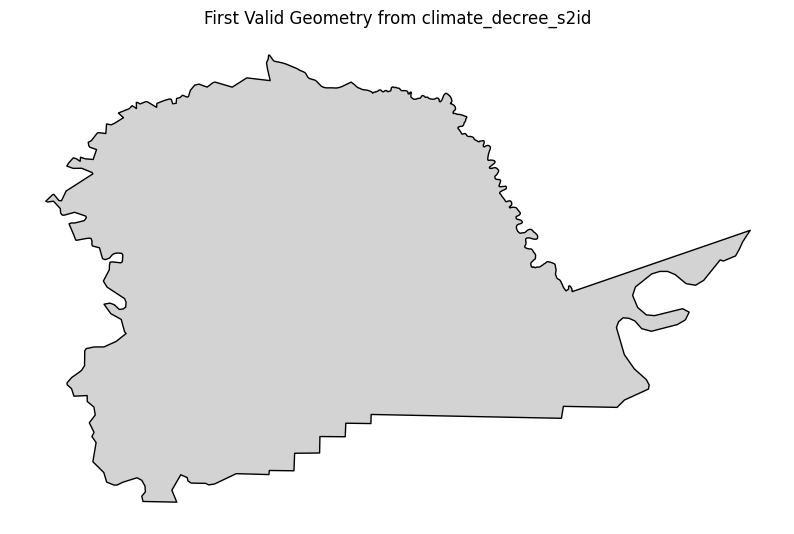

In [ ]:
# import matplotlib.pyplot as plt

# # Filter for rows with valid geometries and plot the first one found.
# first_valid_geometry = climate_decree_s2id[climate_decree_s2id.geometry.notna()].iloc[0].geometry

# if first_valid_geometry is not None:
#     fig, ax = plt.subplots(1, 1, figsize=(10, 10))
#     gpd.GeoSeries([first_valid_geometry]).plot(ax=ax, edgecolor='black', facecolor='lightgray')
#     ax.set_title("First Valid Geometry from climate_decree_s2id")
#     ax.set_axis_off()
#     plt.show()
# else:
#     print("No valid geometry found to plot.")

In [ ]:
print(climate_decree_s2id.shape);climate_decree_s2id.tail(3)

(110358, 30)


,NM_MUN_SEM_ACENTO,SIGLA_UF,geometry,ANO,COD_COBRADE,PEPL_TELECOMUNICACOES (R$),DH_FERIDOS,MES,NM_MUN,PROTOCOLO,...,PEPR_AGRICULTURA (R$),STATUS,COBRADE_NAME,DH_DESABRIGADOS,PEPL_SEGURANCA PUBLICA (R$),DATA_REGISTRO,DESCRICAO_TIPOLOGIA,PEPR_SERVICOS (R$),DH_DESAPARECIDOS,DH_OUTROS AFETADOS
110355,MOCAJUBA,PA,None,2026,13214,0.0,0.0,3,Mocajuba,PA-F-1504604-13214-20260305,...,845000.0,Registro,Tempestade Local/Convectiva - Chuvas Intensas,0.0,0.0,2026-03-15,Chuvas Intensas,86350.0,0.0,10350.0
110356,SAO LUIS,MA,None,2026,22220,0.0,0.0,3,São Luís,MA-F-2111300-22220-20260202,...,0.0,Registro,Derramamento de produtos químicos em ambiente...,24.0,0.0,2026-03-15,Outros,0.0,0.0,0.0
110357,BETANIA DO PIAUI,PI,None,2026,14110,0.0,0.0,3,Betânia do Piauí,PI-F-2201739-14110-20260313,...,1200000.0,Registro,Estiagem,0.0,0.0,2026-03-15,Estiagem e Seca,0.0,0.0,4300.0


In [ ]:
for i in climate_decree_s2id.columns:
  print(i)

NM_MUN_SEM_ACENTO
SIGLA_UF
geometry
ANO
COD_COBRADE
PEPL_TELECOMUNICACOES (R$)
DH_FERIDOS
MES
NM_MUN
PROTOCOLO
DH_DESALOJADOS
DH_MORTOS
GRUPO_DE_DESASTRE
PEPR_PECUARIA (R$)
COBRADE
PEPR_INDUSTRIA (R$)
PEPR_COMERCIO (R$)
PEPL_ENSINO (R$)
DH_ENFERMOS
TIPOLOGIA
PEPR_AGRICULTURA (R$)
STATUS
COBRADE_NAME
DH_DESABRIGADOS
PEPL_SEGURANCA PUBLICA (R$)
DATA_REGISTRO
DESCRICAO_TIPOLOGIA
PEPR_SERVICOS (R$)
DH_DESAPARECIDOS
DH_OUTROS AFETADOS


In [ ]:
climate_risk = gpd.read_parquet('/content/drive/MyDrive/workspace/skyvidya/00_pocs_ingestao_ciencia/mdr/02_silver/climate_risk.geoparquet')
print(climate_risk.shape);climate_risk.head(3)

(499, 521)


,CD_MUN,geometry,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,...,LAST10_YEARS_COUNT_POR_10K_HAB_22460,LAST10_YEARS_COUNT_POR_10K_HAB_23110,LAST10_YEARS_COUNT_POR_10K_HAB_23120,LAST10_YEARS_COUNT_POR_10K_HAB_24100,LAST10_YEARS_COUNT_POR_10K_HAB_24200,LAST10_YEARS_COUNT_POR_10K_HAB_25100,LAST10_YEARS_COUNT_POR_10K_HAB_25200,LAST10_YEARS_COUNT_POR_10K_HAB_25300,LAST10_YEARS_COUNT_POR_10K_HAB_25400,LAST10_YEARS_COUNT_POR_10K_HAB_25500
0,4300001,"POLYGON ((-52.62752 -32.15022, -52.62816 -32.1...",N/A,N/A,N/A,None,43,Rio Grande do Sul,RS,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4300002,"POLYGON ((-51.31995 -30.14806, -51.31993 -30.1...",N/A,N/A,N/A,None,43,Rio Grande do Sul,RS,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4300034,"POLYGON ((-54.21884 -31.82901, -54.23601 -31.8...",430010,Bagé,4302,Pelotas,43,Rio Grande do Sul,RS,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(climate_decree_s2id.shape);climate_decree_s2id.tail(3)

(110358, 30)


,NM_MUN_SEM_ACENTO,SIGLA_UF,geometry,ANO,COD_COBRADE,PEPL_TELECOMUNICACOES (R$),DH_FERIDOS,MES,NM_MUN,PROTOCOLO,...,PEPR_AGRICULTURA (R$),STATUS,COBRADE_NAME,DH_DESABRIGADOS,PEPL_SEGURANCA PUBLICA (R$),DATA_REGISTRO,DESCRICAO_TIPOLOGIA,PEPR_SERVICOS (R$),DH_DESAPARECIDOS,DH_OUTROS AFETADOS
110355,MOCAJUBA,PA,None,2026,13214,0.0,0.0,3,Mocajuba,PA-F-1504604-13214-20260305,...,845000.0,Registro,Tempestade Local/Convectiva - Chuvas Intensas,0.0,0.0,2026-03-15,Chuvas Intensas,86350.0,0.0,10350.0
110356,SAO LUIS,MA,None,2026,22220,0.0,0.0,3,São Luís,MA-F-2111300-22220-20260202,...,0.0,Registro,Derramamento de produtos químicos em ambiente...,24.0,0.0,2026-03-15,Outros,0.0,0.0,0.0
110357,BETANIA DO PIAUI,PI,None,2026,14110,0.0,0.0,3,Betânia do Piauí,PI-F-2201739-14110-20260313,...,1200000.0,Registro,Estiagem,0.0,0.0,2026-03-15,Estiagem e Seca,0.0,0.0,4300.0


In [ ]:
for i in climate_risk.columns:
  print(i)

CD_MUN
geometry
CD_RGI
NM_RGI
CD_RGINT
NM_RGINT
CD_UF
NM_UF
SIGLA_UF
CD_REGIA
NM_REGIA
SIGLA_RG
CD_CONCU
NM_CONCU
AREA_KM2
CENSO_2020_POP
NM_MUN_SEM_ACENTO
HISTORIC_COUNT
LAST10_YEARS_COUNT
LAST05_YEARS_COUNT
LAST02_YEARS_COUNT
HISTORIC_COUNT_POR_10K_HAB
LAST10_YEARS_COUNT_POR_10K_HAB
LAST05_YEARS_COUNT_POR_10K_HAB
LAST02_YEARS_COUNT_POR_10K_HAB
HISTORIC_COUNT_11110
HISTORIC_COUNT_11120
HISTORIC_COUNT_11311
HISTORIC_COUNT_11312
HISTORIC_COUNT_11313
HISTORIC_COUNT_11314
HISTORIC_COUNT_11321
HISTORIC_COUNT_11331
HISTORIC_COUNT_11332
HISTORIC_COUNT_11340
HISTORIC_COUNT_11410
HISTORIC_COUNT_11420
HISTORIC_COUNT_11431
HISTORIC_COUNT_11432
HISTORIC_COUNT_11433
HISTORIC_COUNT_12100
HISTORIC_COUNT_12200
HISTORIC_COUNT_12300
HISTORIC_COUNT_13111
HISTORIC_COUNT_13112
HISTORIC_COUNT_13120
HISTORIC_COUNT_13211
HISTORIC_COUNT_13212
HISTORIC_COUNT_13213
HISTORIC_COUNT_13214
HISTORIC_COUNT_13215
HISTORIC_COUNT_13310
HISTORIC_COUNT_13321
HISTORIC_COUNT_13322
HISTORIC_COUNT_14110
HISTORIC_COUNT_14120
H